# Loan Default Prediction - Drift monitoring demo

**Why monitor drift?** A model learns from past loans. If new applicants start to look different (higher interest
rates, lower incomes, other loan purposes), the model may become wrong without anybody noticing. Drift monitoring
compares new applications with the training data and raises an alarm when they differ too much.

**Our dataset has no dates**, so we cannot watch it change over time. Instead `src/simulate_batches.py` builds two
"current" batches of 2,000 loans from the test split:
- **no_drift**: a plain random sample - the alarm should stay quiet;
- **drift**: interest rates +3 points, incomes -15%, and debt consolidation + medical loans raised to 50% of the batch.

`src/drift.py` compares each batch with the training split using **Evidently** and the **PSI** of the predicted
probability. Alert rule: more than 30% of the 11 features drifted, or prediction PSI above 0.2 -> **DRIFT DETECTED**.

In [1]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT / "src"))
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="IProgress not found")   # harmless notice from tqdm
import train  # noqa: F401 - project chart style
%matplotlib inline
from train import INK, INK2, MUTED
import drift
from drift import DRIFT_SHARE_ALARM, PSI_ALARM, run_drift_check
from load_data import FEATURES
from simulate_batches import SHIFTED_INTENTS, describe, load_batch, raw_test_loans

FIG = PROJECT / "reports" / "figures"
GREY, BLUE, ORANGE = "#898781", "#2a78d6", "#eb6834"
pd.set_option("display.precision", 3)
batches = {"no_drift": load_batch("no_drift"), "drift": load_batch("drift")}
reference_X, reference_p = drift._reference()

## 1. What changed in the batches?

In [2]:
pd.DataFrame({"test split": describe(raw_test_loans()), "no_drift batch": describe(batches["no_drift"]),
              "drift batch": describe(batches["drift"])})

,test split,no_drift batch,drift batch
interest rate (mean %),10.929,11.037,13.942
yearly income (mean $),66105.786,64421.440,56730.297
loan / income (mean),0.170,0.170,0.197
debt consolidation + medical (share),0.345,0.349,0.500
interest rate missing (share),0.097,0.098,0.108


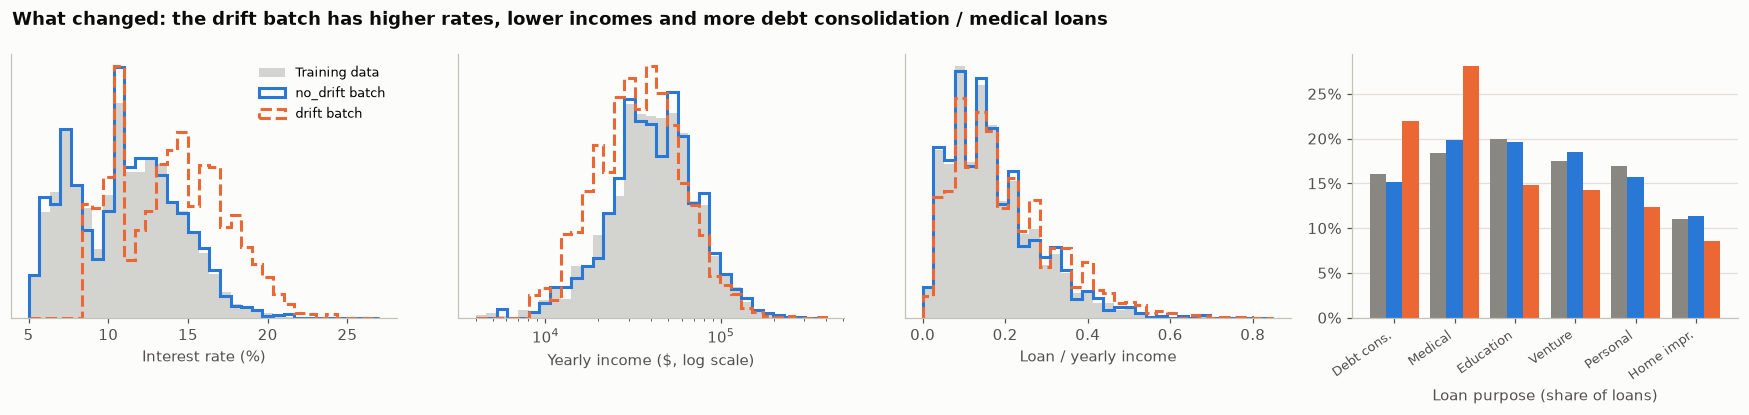

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
specs = [("loan_int_rate", "Interest rate (%)", np.linspace(5, 27, 34)),
         ("person_income", "Yearly income ($, log scale)", np.logspace(np.log10(4000), np.log10(400000), 34)),
         ("loan_percent_income", "Loan / yearly income", np.linspace(0, 0.85, 34))]
for ax, (col, label, bins) in zip(axes, specs):
    ax.hist(reference_X[col].dropna(), bins=bins, density=True, histtype="stepfilled", color=GREY, alpha=0.35, label="Training data")
    ax.hist(batches["no_drift"][col].dropna(), bins=bins, density=True, histtype="step", lw=2, color=BLUE, label="no_drift batch")
    ax.hist(batches["drift"][col].dropna(), bins=bins, density=True, histtype="step", lw=2, ls="--", color=ORANGE, label="drift batch")
    if col == "person_income":
        ax.set_xscale("log")
    ax.set_xlabel(label); ax.set_yticks([]); ax.grid(False)
axes[0].legend(loc="upper right", fontsize=8.5)
shares = pd.DataFrame({
    "Training data": reference_X["loan_intent"].value_counts(normalize=True),
    "no_drift batch": batches["no_drift"]["loan_intent"].value_counts(normalize=True),
    "drift batch": batches["drift"]["loan_intent"].value_counts(normalize=True),
}).loc[["DEBTCONSOLIDATION", "MEDICAL", "EDUCATION", "VENTURE", "PERSONAL", "HOMEIMPROVEMENT"]]
x = np.arange(len(shares))
for i, (name, color) in enumerate(zip(shares.columns, [GREY, BLUE, ORANGE])):
    axes[3].bar(x + (i - 1) * 0.27, shares[name], width=0.27, color=color, label=name)
axes[3].set_xticks(x, ["Debt cons.", "Medical", "Education", "Venture", "Personal", "Home impr."], rotation=35, ha="right", fontsize=8.5)
axes[3].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
axes[3].set_xlabel("Loan purpose (share of loans)"); axes[3].grid(axis="x", visible=False)
fig.suptitle("What changed: the drift batch has higher rates, lower incomes and more debt consolidation / medical loans",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(FIG / "26_drift_batches.png")
plt.show()

**Insight:** the **no_drift** batch looks like the training data (mean interest 11.0%, income $64,421, debt consolidation
+ medical 35%). In the **drift** batch the mean interest rate rises from 10.9% to **13.9%**, mean income falls from
$66,106 to **$56,730**, loan / income rises from 0.170 to **0.197**, and debt consolidation + medical loans make up
**50%** instead of 35%. Age, grade, home ownership and loan amount were not changed.

## 2. Which features drift? (Evidently)

In [4]:
results = {name: run_drift_check(batch, name, save=False) for name, batch in batches.items()}
scores = pd.DataFrame({name: {f: r["features"][f]["score"] for f in FEATURES} for name, r in results.items()})
scores["test"] = [results["drift"]["features"][f]["method"] for f in FEATURES]
scores["threshold"] = [results["drift"]["features"][f]["threshold"] for f in FEATURES]
scores = scores.sort_values("drift", ascending=False)
summary = pd.DataFrame({name: {"features drifted": f"{r['n_drifted']} of 11 ({r['drift_share']:.0%})",
                               "prediction PSI": round(r["prediction_psi"], 3),
                               "mean predicted probability": f"{r['mean_probability']['current']:.1%}",
                               "share in REJECT band": f"{r['reject_share']['current']:.1%}",
                               "status": r["status"]} for name, r in results.items()})
display(summary)
scores

,no_drift,drift
features drifted,0 of 11 (0%),4 of 11 (36%)
prediction PSI,0.007,0.198
mean predicted probability,22.0%,30.8%
share in REJECT band,17.9%,26.4%
status,NO DRIFT,DRIFT DETECTED


,no_drift,drift,test,threshold
loan_int_rate,0.018,0.897,Wasserstein distance (normed),0.1
loan_percent_income,0.014,0.250,Wasserstein distance (normed),0.1
person_income,0.046,0.173,Wasserstein distance (normed),0.1
loan_intent,0.019,0.113,Jensen-Shannon distance,0.1
loan_amnt,0.016,0.033,Wasserstein distance (normed),0.1
person_emp_length,0.039,0.028,Wasserstein distance (normed),0.1
cb_person_cred_hist_length,0.027,0.027,Wasserstein distance (normed),0.1
person_age,0.039,0.021,Wasserstein distance (normed),0.1
loan_grade_num,0.019,0.019,Wasserstein distance (normed),0.1
cb_person_default_on_file,0.002,0.006,Jensen-Shannon distance,0.1


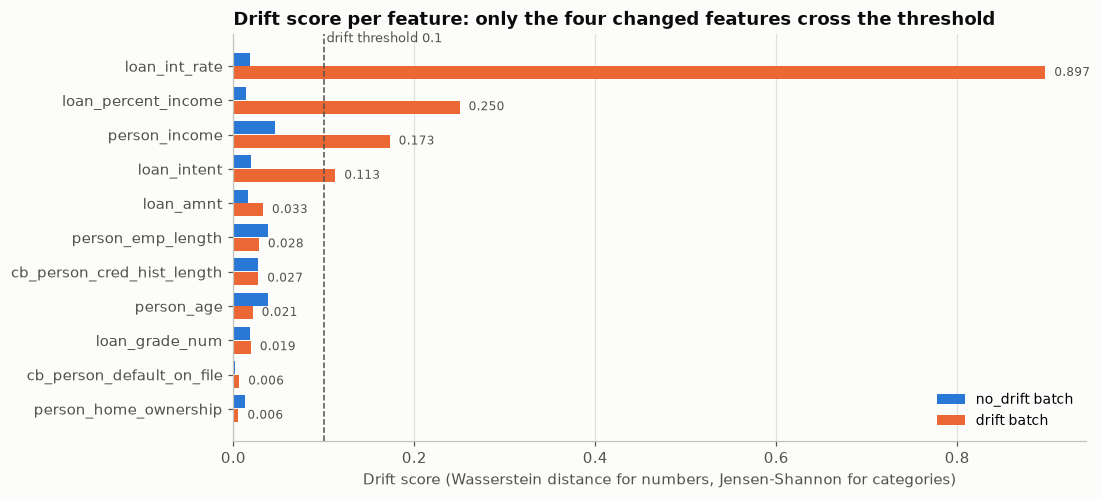

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(scores))[::-1]
ax.barh(y + 0.2, scores["no_drift"], height=0.38, color=BLUE, label="no_drift batch")
ax.barh(y - 0.2, scores["drift"], height=0.38, color=ORANGE, label="drift batch")
ax.axvline(0.1, color=INK2, ls="--", lw=1)
ax.text(0.103, y.max() + 0.6, "drift threshold 0.1", color=INK2, fontsize=8.5, va="bottom")
for yi, v in zip(y, scores["drift"]):
    ax.text(v + 0.01, yi - 0.2, f"{v:.3f}", va="center", fontsize=8, color=INK2)
ax.set_yticks(y, scores.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("Drift score (Wasserstein distance for numbers, Jensen-Shannon for categories)")
ax.set_title("Drift score per feature: only the four changed features cross the threshold")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(FIG / "27_drift_scores.png")
plt.show()

**Insight:** in the **drift** batch exactly the four changed features cross the 0.1 threshold: **interest rate (0.897)**,
**loan / income (0.250)**, **income (0.173)** and **loan purpose (0.113)** - 4 of 11 features = **36%**, above the
30% alarm line, so the status is **DRIFT DETECTED**. Every other feature stays below 0.05. In the **no_drift** batch
no feature drifts (highest score 0.046) -> **NO DRIFT**. The monitoring finds the changes we made and nothing else.

## 3. Does the model's output change? (prediction drift)

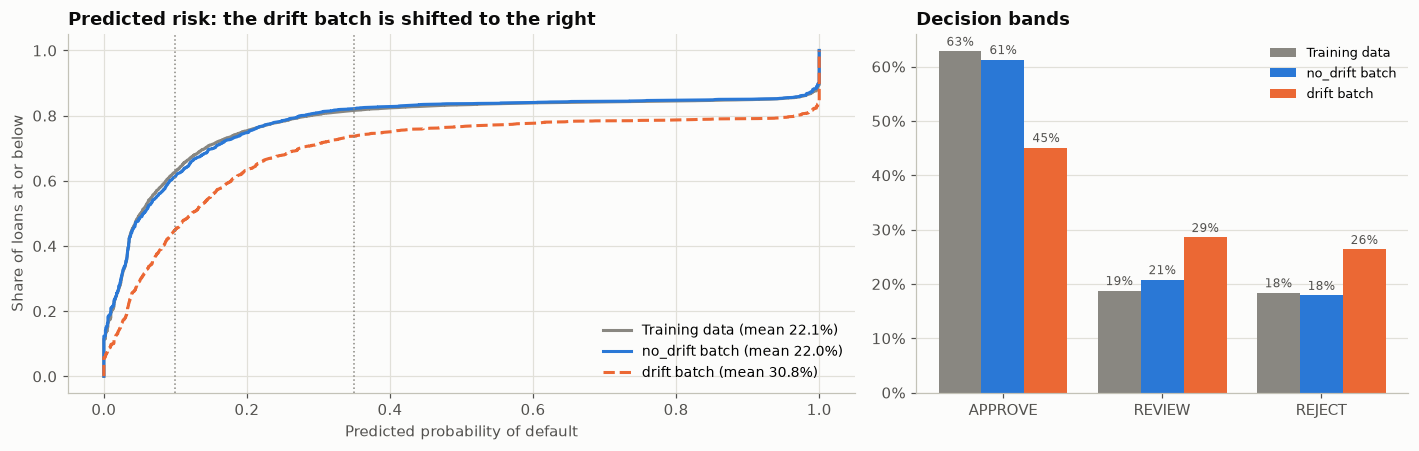

,Training data,no_drift batch,drift batch
APPROVE,0.628,0.613,0.451
REVIEW,0.188,0.208,0.285
REJECT,0.184,0.179,0.264


In [6]:
probs = {"Training data": reference_p}
for name, batch in batches.items():
    probs[f"{name} batch"] = drift._model().predict_proba(drift.to_model_input(batch.drop(columns="loan_id")))[:, 1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
for (name, p), color, ls in zip(probs.items(), [GREY, BLUE, ORANGE], ["-", "-", "--"]):
    xs = np.sort(p)
    a1.plot(xs, np.arange(1, len(xs) + 1) / len(xs), color=color, ls=ls, lw=2, label=f"{name} (mean {p.mean():.1%})")
cut = drift._cutoffs()
for c in (cut["review"], cut["reject"]):
    a1.axvline(c, color=MUTED, ls=":", lw=1)
a1.set_xlabel("Predicted probability of default"); a1.set_ylabel("Share of loans at or below")
a1.set_title("Predicted risk: the drift batch is shifted to the right")
a1.legend(loc="lower right", fontsize=9)
bands = pd.DataFrame({name: pd.Series(pd.cut(p, [-0.01, cut["review"], cut["reject"], 1.01],
                                             labels=["APPROVE", "REVIEW", "REJECT"])).value_counts(normalize=True)
                      for name, p in probs.items()}).loc[["APPROVE", "REVIEW", "REJECT"]]
x = np.arange(3)
for i, (name, color) in enumerate(zip(bands.columns, [GREY, BLUE, ORANGE])):
    a2.bar(x + (i - 1) * 0.27, bands[name], width=0.27, color=color, label=name)
    for xi, v in zip(x, bands[name]):
        a2.text(xi + (i - 1) * 0.27, v + 0.01, f"{v:.0%}", ha="center", fontsize=8, color=INK2)
a2.set_xticks(x, bands.index); a2.grid(axis="x", visible=False)
a2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
a2.set_title("Decision bands")
a2.legend(loc="upper right", fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG / "28_prediction_drift.png")
plt.show()
bands

**Insight:** for the **no_drift** batch the model's output matches the training data (mean predicted probability
22.0% vs 22.1%, PSI **0.007**). For the **drift** batch the predicted risk rises to **30.8%** on average and the REJECT
band grows from 18% to **26%** of loans; the PSI is **0.198** - just under the 0.2 alarm line on its own, so here the
alarm comes from the feature drift. That is why the rule uses both signals: features can shift a lot before the
predictions cross their own threshold.

## 4. What do we do when drift is detected? Retraining with a safety check
`src/retrain.py` trains a candidate model with the same tuned settings on the old training data plus new **labelled**
loans, and compares it with the production model on a hold-out of new loans. Rule: **replace only if the candidate is
not worse**. The simulated drift batch has no true outcomes after its feature changes, so the demo uses the same
2,000 intent-resampled test loans **before** the changes, with their real outcomes (half for training, half as hold-out).

In [7]:
log = pd.read_csv(PROJECT / "reports" / "retrain_log.csv")
last = log.iloc[-1]
pd.Series({
    "new loans added to training": int(last["n_new_added"]),
    "hold-out loans": int(last["n_holdout"]),
    "production model ROC-AUC (hold-out)": f"{last['production_auc']:.4f}",
    "candidate model ROC-AUC (hold-out)": f"{last['candidate_auc']:.4f}",
    "decision": last["decision"],
    "carried out": "yes" if last["applied"] else "no (demo run without --apply)",
}, name="latest retraining check").to_frame()

,latest retraining check
new loans added to training,1000
hold-out loans,1000
production model ROC-AUC (hold-out),0.9596
candidate model ROC-AUC (hold-out),0.9609
decision,REPLACE
carried out,no (demo run without --apply)


**Insight:** the candidate scores **0.9609** ROC-AUC on the 1,000 hold-out loans vs **0.9596** for the production
model, so the rule says **REPLACE** (it is not worse). The difference of 0.0013 is tiny - within normal sampling noise -
so both models are equally good here; the rule simply prefers the newer data when it is not worse.

The demo does **not** carry the replacement out by default: the new loans come from the test split, so a model trained
on them would make the Step 4 test metrics, the business simulation and the SHAP report describe a different model.
`python src/retrain.py --apply` performs the replacement (backing up the current model first, registering a new MLflow
version with the `production` alias); `--restore` puts the backup back. **The official metrics stay the Step 4 test numbers.**

## 5. Summary

| | no_drift batch | drift batch |
|---|---|---|
| Features drifted | 0 of 11 | **4 of 11 (36%)**: interest rate, loan / income, income, loan purpose |
| Prediction PSI | 0.007 | 0.198 |
| Mean predicted probability (training 22.1%) | 22.0% | **30.8%** |
| Status | NO DRIFT | **DRIFT DETECTED** |

In the running system the same check runs **every day at 02:00** on the applications of the last 30 days (APScheduler
inside the API; skipped with a message when fewer than 50 are stored), or on demand from the Dashboard /
`POST /monitoring/drift/run`. Each check is stored in the `drift_reports` table and shown on the Dashboard; the full
interactive Evidently report is saved in `reports/drift/`.